# AudioCNN Training & Evaluation

This notebook documents the full training and evaluation pipeline for the **AudioCNN** binary classifier that distinguishes **Human-Made** music (GTZAN dataset) from **AI-Generated** music (SONICS dataset).

## Contents
1. Setup & Imports
2. Dataset Statistics
3. Sample Mel Spectrograms
4. Training (or load saved metrics)
5. Training Curves
6. Confusion Matrix & ROC Curve
7. Classification Report
8. Ablation: 3-block vs 4-block CNN

In [1]:
import os
import sys
import json
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_score, recall_score, f1_score,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# Add project root to path
PROJECT_ROOT = Path(os.getcwd()).parent if "notebooks" in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

from backend.cnn_model import AudioCNN
from training.train import preprocess_audio, AudioDataset, collect_files, SAMPLE_RATE, MAX_MS, N_MELS

plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Project root: {PROJECT_ROOT}")

Device: cpu
Project root: /private/tmp/MusicSourceClassifier


/Volumes/PortableSSD/SynthtoSoul/SynthToSoul-main/venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset Statistics

We use two datasets:
- **GTZAN** (label=0, "human"): 1,000 tracks across 10 genres, each 30 seconds
- **SONICS** (label=1, "AI"): AI-generated music tracks from multiple generators

Collected 1000 human + 5000 AI = 6000 total files
Human (GTZAN): 1000 tracks
AI (SONICS):   5000 tracks
Total:         6000 tracks


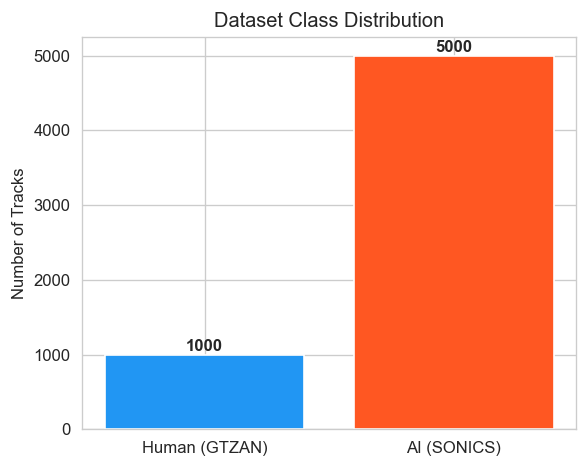

In [2]:
DATA_DIR = PROJECT_ROOT / "data"

if DATA_DIR.exists():
    paths, labels = collect_files(DATA_DIR)
    human_count = labels.count(0)
    ai_count = labels.count(1)
    print(f"Human (GTZAN): {human_count} tracks")
    print(f"AI (SONICS):   {ai_count} tracks")
    print(f"Total:         {len(labels)} tracks")
    
    # Class distribution bar chart
    fig, ax = plt.subplots(figsize=(5, 4))
    bars = ax.bar(["Human (GTZAN)", "AI (SONICS)"], [human_count, ai_count],
                  color=["#2196F3", "#FF5722"])
    ax.set_ylabel("Number of Tracks")
    ax.set_title("Dataset Class Distribution")
    for bar, count in zip(bars, [human_count, ai_count]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                str(count), ha="center", va="bottom", fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Dataset not found. Download with:")
    print("  python training/download_datasets.py --output-dir data/")
    paths, labels = [], []

## 2. Sample Mel Spectrograms

Visualize sample Mel spectrograms from each class to understand the input representation.

Saved to /private/tmp/MusicSourceClassifier/results/mel_spectrogram_samples.png


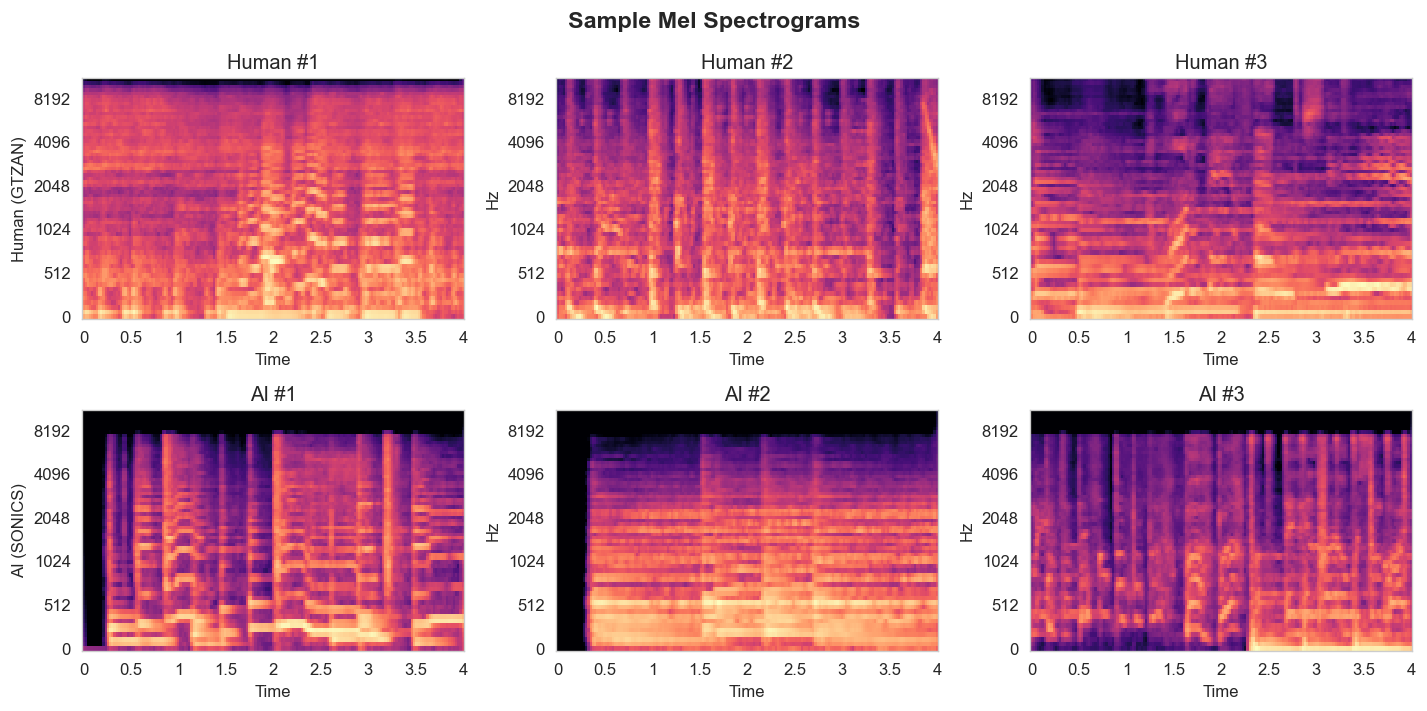

In [3]:
def plot_mel_spectrograms(paths, labels, n_samples=3, save_path=None):
    """Plot sample Mel spectrograms for human and AI tracks."""
    human_paths = [p for p, l in zip(paths, labels) if l == 0]
    ai_paths = [p for p, l in zip(paths, labels) if l == 1]
    
    rng = np.random.RandomState(42)
    human_samples = rng.choice(human_paths, min(n_samples, len(human_paths)), replace=False)
    ai_samples = rng.choice(ai_paths, min(n_samples, len(ai_paths)), replace=False)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(4 * n_samples, 6))
    if n_samples == 1:
        axes = axes.reshape(2, 1)
    
    for i, path in enumerate(human_samples):
        y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=MAX_MS/1000)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        S_db = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[0, i])
        axes[0, i].set_title(f"Human #{i+1}")
    
    for i, path in enumerate(ai_samples):
        y, sr = librosa.load(path, sr=SAMPLE_RATE, duration=MAX_MS/1000)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
        S_db = librosa.power_to_db(S, ref=np.max)
        librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, i])
        axes[1, i].set_title(f"AI #{i+1}")
    
    axes[0, 0].set_ylabel("Human (GTZAN)")
    axes[1, 0].set_ylabel("AI (SONICS)")
    fig.suptitle("Sample Mel Spectrograms", fontsize=14, fontweight="bold")
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()

if paths:
    os.makedirs(str(PROJECT_ROOT / "results"), exist_ok=True)
    plot_mel_spectrograms(paths, labels, n_samples=3,
                          save_path=str(PROJECT_ROOT / "results" / "mel_spectrogram_samples.png"))
else:
    print("Skipped: no dataset available.")

## 3. Training

If a training log CSV already exists, we load it. Otherwise, run training from the CLI.

**To train from scratch**, run:
```bash
python training/train.py --data-dir data/ --epochs 25 --batch-size 32
```

In [4]:
RESULTS_DIR = PROJECT_ROOT / "results"
CSV_PATH = RESULTS_DIR / "training_log.csv"

if CSV_PATH.exists():
    print(f"Loading training history from {CSV_PATH}")
    history_df = pd.read_csv(CSV_PATH)
    print(f"Loaded {len(history_df)} epochs of training history")
    display(history_df)
else:
    print("No training log found. Run training first:")
    print("  python training/train.py --data-dir data/ --epochs 25 --batch-size 32")
    history_df = None

Loading training history from /private/tmp/MusicSourceClassifier/results/training_log.csv
Loaded 7 epochs of training history


,epoch,train_loss,val_loss,train_acc,val_acc,lr,time_s
0,1,0.02540,0.00014,0.99619,1.0,0.00100,196.2
1,2,0.00024,0.00001,1.00000,1.0,0.00100,191.6
2,3,0.00009,0.00001,1.00000,1.0,0.00100,190.8
3,4,0.00005,0.00001,1.00000,1.0,0.00100,191.2
4,5,0.00003,0.00000,1.00000,1.0,0.00050,190.5
5,6,0.00002,0.00000,1.00000,1.0,0.00050,191.0
6,7,0.00001,0.00000,1.00000,1.0,0.00025,190.7


## 4. Training Curves

Plot train vs validation loss and accuracy over epochs.

Saved to /private/tmp/MusicSourceClassifier/results/training_curves.png


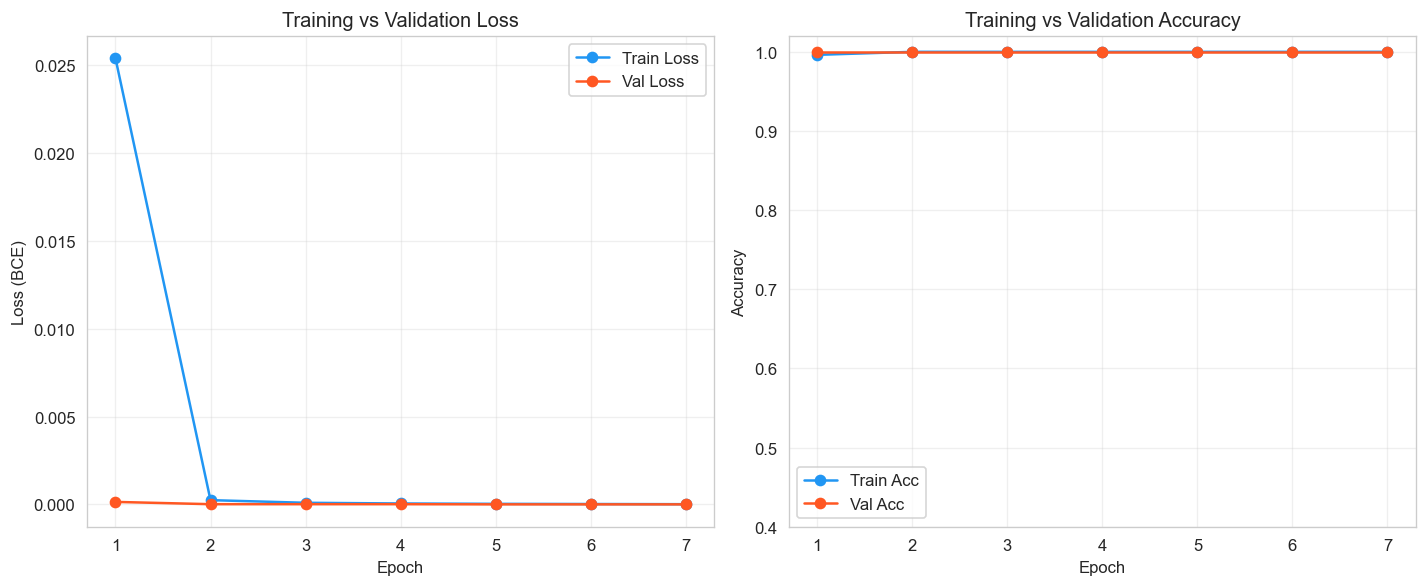

In [5]:
def plot_training_curves(df, save_path=None):
    """Plot training and validation loss/accuracy curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Loss
    ax1.plot(df["epoch"], df["train_loss"], "o-", label="Train Loss", color="#2196F3")
    ax1.plot(df["epoch"], df["val_loss"], "o-", label="Val Loss", color="#FF5722")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (BCE)")
    ax1.set_title("Training vs Validation Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy
    ax2.plot(df["epoch"], df["train_acc"], "o-", label="Train Acc", color="#2196F3")
    ax2.plot(df["epoch"], df["val_acc"], "o-", label="Val Acc", color="#FF5722")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Training vs Validation Accuracy")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0.4, 1.02])
    
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to {save_path}")
    plt.show()

if history_df is not None:
    plot_training_curves(history_df,
                         save_path=str(RESULTS_DIR / "training_curves.png"))
else:
    print("Skipped: no training history available.")

## 5. Confusion Matrix & ROC Curve

Load the best model and run on the held-out test set.

In [6]:
MODEL_PATH = RESULTS_DIR / "best_model.pth"
MANIFEST_PATH = RESULTS_DIR / "test_manifest.json"
has_results = False

if MODEL_PATH.exists() and MANIFEST_PATH.exists():
    # Load model
    model = AudioCNN().to(device)
    checkpoint = torch.load(str(MODEL_PATH), map_location=device, weights_only=False)
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    
    # Load test set
    with open(MANIFEST_PATH) as f:
        manifest = json.load(f)
    test_ds = AudioDataset(manifest["paths"], manifest["labels"])
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
    
    # Inference
    all_probs, all_labels = [], []
    with torch.no_grad():
        for specs, labs in tqdm(test_loader, desc="Running test inference"):
            specs = specs.to(device)
            outputs = model(specs)
            all_probs.extend(outputs.cpu().numpy().flatten().tolist())
            all_labels.extend(labs.numpy().flatten().tolist())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels, dtype=int)
    all_preds = (all_probs >= 0.5).astype(int)
    has_results = True
    print(f"Test set: {len(all_labels)} samples")
else:
    print("Model or test manifest not found. Run training first.")

Running test inference:   0%|          | 0/29 [00:00<?, ?it/s]

Running test inference:   3%|▎         | 1/29 [00:01<00:39,  1.41s/it]

Running test inference:   7%|▋         | 2/29 [00:02<00:28,  1.05s/it]

Running test inference:  10%|█         | 3/29 [00:03<00:24,  1.06it/s]

Running test inference:  14%|█▍        | 4/29 [00:03<00:22,  1.09it/s]

...

Running test inference:  93%|█████████▎| 27/29 [00:25<00:01,  1.08it/s]

Running test inference:  97%|█████████▋| 28/29 [00:26<00:00,  1.03it/s]

Running test inference: 100%|██████████| 29/29 [00:26<00:00,  1.38it/s]

Running test inference: 100%|██████████| 29/29 [00:26<00:00,  1.10it/s]

Test set: 900 samples


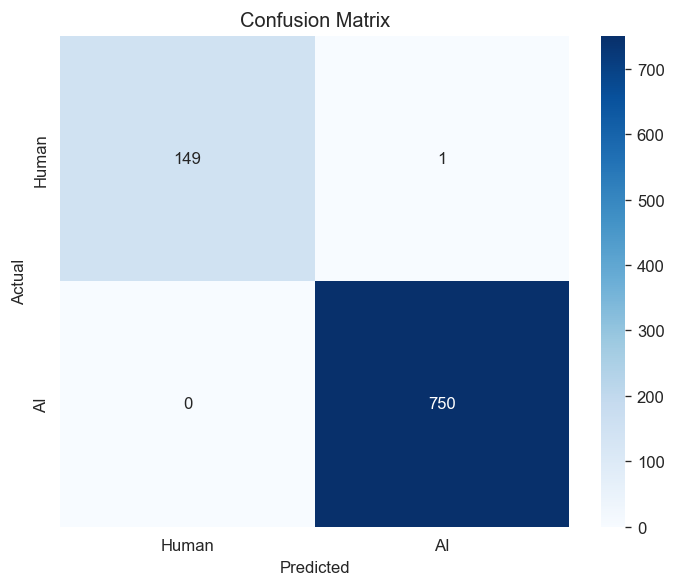

In [7]:
if has_results:
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Human", "AI"], yticklabels=["Human", "AI"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

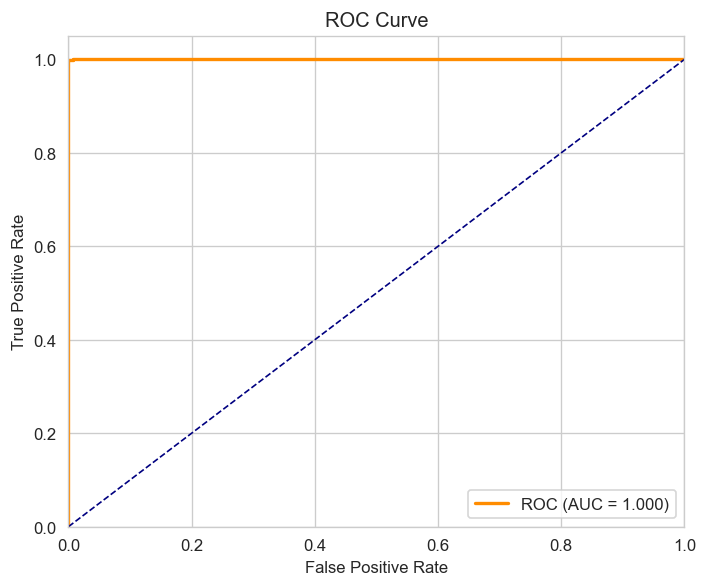

In [8]:
if has_results:
    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 6. Classification Report

In [9]:
if has_results:
    report = classification_report(all_labels, all_preds,
                                    target_names=["human", "ai"], digits=4)
    print(report)
    print(f"AUC-ROC: {roc_auc:.4f}")
    
    # Also show saved metrics if available
    metrics_path = RESULTS_DIR / "eval_metrics.json"
    if metrics_path.exists():
        with open(metrics_path) as f:
            saved = json.load(f)
        print("\nSaved metrics:")
        for k, v in saved.items():
            print(f"  {k}: {v}")

              precision    recall  f1-score   support

       human     1.0000    0.9933    0.9967       150
          ai     0.9987    1.0000    0.9993       750

    accuracy                         0.9989       900
   macro avg     0.9993    0.9967    0.9980       900
weighted avg     0.9989    0.9989    0.9989       900

AUC-ROC: 1.0000

Saved metrics:
  test_accuracy: 0.99889
  precision_human: 1.0
  recall_human: 0.99333
  f1_human: 0.99666
  precision_ai: 0.99867
  recall_ai: 1.0
  f1_ai: 0.99933
  auc_roc: 0.99999
  num_test_samples: 900
  num_human: 150
  num_ai: 750


## 7. Ablation Study: 3-Block vs 4-Block CNN

Compare the standard 4-block AudioCNN with a reduced 3-block variant to understand the impact of network depth.

In [10]:
class AudioCNN3Block(nn.Module):
    """3-block variant of AudioCNN for ablation study.
    
    Removes the 4th conv block (128->256) and connects
    the 128-channel output directly to global average pooling.
    """
    def __init__(self, dropout_rate=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 64)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(64, 1)
    
    def forward(self, x):
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

model_3b = AudioCNN3Block()
model_4b = AudioCNN()
params_3b = sum(p.numel() for p in model_3b.parameters())
params_4b = sum(p.numel() for p in model_4b.parameters())
print(f"3-block CNN: {params_3b:,} parameters")
print(f"4-block CNN: {params_4b:,} parameters")
print(f"Reduction:   {params_4b - params_3b:,} fewer parameters ({(1 - params_3b/params_4b)*100:.1f}%)")

3-block CNN: 101,441 parameters
4-block CNN: 421,825 parameters
Reduction:   320,384 fewer parameters (76.0%)


=== Ablation: 3-block CNN (3 epochs) ===


/private/tmp/MusicSourceClassifier/training/train.py:63: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, _ = librosa.load(file_path, sr=SAMPLE_RATE)
/Volumes/PortableSSD/SynthtoSoul/SynthToSoul-main/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [skip] /private/tmp/MusicSourceClassifier/data/gtzan/jazz_jazz.00054.wav: 


  Epoch 1: train_acc=0.9788  val_acc=1.0000


/private/tmp/MusicSourceClassifier/training/train.py:63: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, _ = librosa.load(file_path, sr=SAMPLE_RATE)
/Volumes/PortableSSD/SynthtoSoul/SynthToSoul-main/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


...

  [skip] /private/tmp/MusicSourceClassifier/data/gtzan/jazz_jazz.00054.wav: 


  Epoch 2: train_acc=0.9998  val_acc=1.0000


/private/tmp/MusicSourceClassifier/training/train.py:63: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform, _ = librosa.load(file_path, sr=SAMPLE_RATE)
/Volumes/PortableSSD/SynthtoSoul/SynthToSoul-main/venv312/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [skip] /private/tmp/MusicSourceClassifier/data/gtzan/jazz_jazz.00054.wav: 


  Epoch 3: train_acc=1.0000  val_acc=1.0000


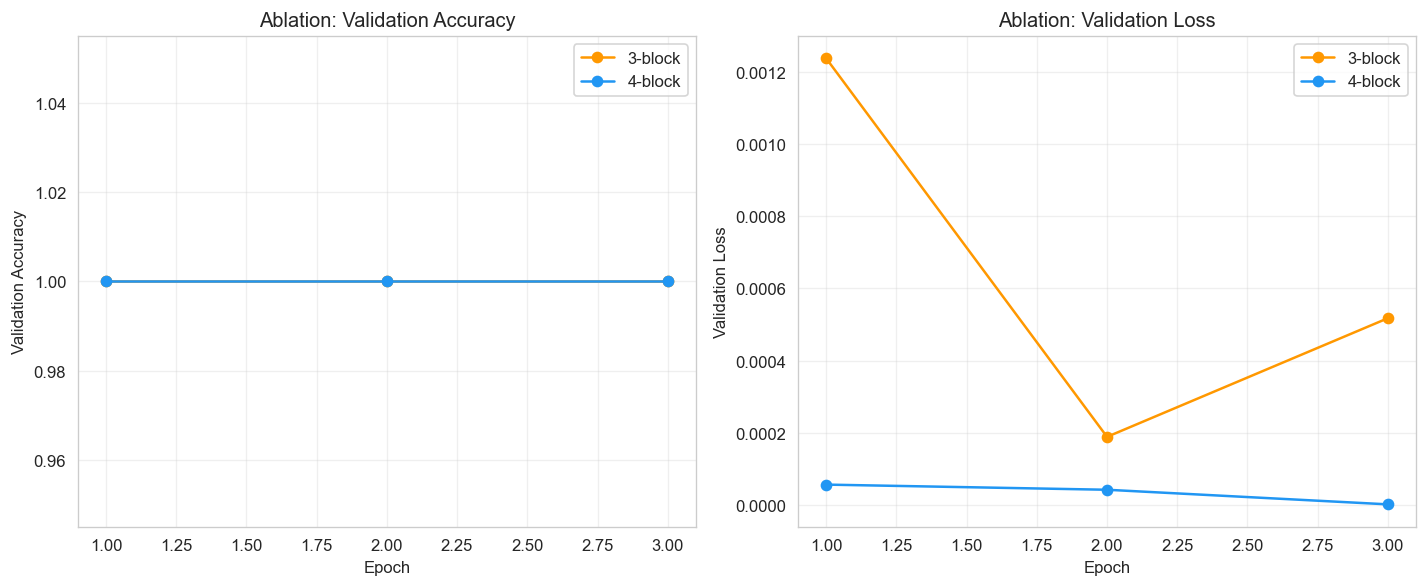


--- Ablation Summary ---
3-block final val_acc: 1.0000
4-block final val_acc: 1.0000
Difference: +0.0000 (4-block worse)


In [11]:
def train_ablation(model, train_loader, val_loader, epochs=3, lr=1e-3):
    """Quick training run for ablation comparison."""
    model = model.to(device)
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = []
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for specs, labs in train_loader:
            specs, labs = specs.to(device), labs.to(device)
            optimizer.zero_grad()
            out = model(specs)
            loss = criterion(out, labs)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * specs.size(0)
            train_correct += ((out >= 0.5).float() == labs).sum().item()
            train_total += specs.size(0)
        
        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for specs, labs in val_loader:
                specs, labs = specs.to(device), labs.to(device)
                out = model(specs)
                loss = criterion(out, labs)
                val_loss += loss.item() * specs.size(0)
                val_correct += ((out >= 0.5).float() == labs).sum().item()
                val_total += specs.size(0)
        
        history.append({
            "epoch": epoch,
            "train_acc": train_correct / train_total,
            "val_acc": val_correct / val_total,
            "train_loss": train_loss / train_total,
            "val_loss": val_loss / val_total,
        })
        print(f"  Epoch {epoch}: train_acc={history[-1]['train_acc']:.4f}  val_acc={history[-1]['val_acc']:.4f}")
    
    return pd.DataFrame(history)


if paths:
    # Create data splits for ablation
    train_p, temp_p, train_l, temp_l = train_test_split(
        paths, labels, test_size=0.3, stratify=labels, random_state=42)
    val_p, _, val_l, _ = train_test_split(
        temp_p, temp_l, test_size=0.5, stratify=temp_l, random_state=42)
    
    train_ds = AudioDataset(train_p, train_l)
    val_ds = AudioDataset(val_p, val_l)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0)
    
    ABLATION_EPOCHS = 3
    print(f"=== Ablation: 3-block CNN ({ABLATION_EPOCHS} epochs) ===")
    hist_3b = train_ablation(AudioCNN3Block(), train_loader, val_loader, epochs=ABLATION_EPOCHS)
    
    print(f"\n=== Ablation: 4-block CNN ({ABLATION_EPOCHS} epochs) ===")
    hist_4b = train_ablation(AudioCNN(), train_loader, val_loader, epochs=ABLATION_EPOCHS)
    
    # Plot comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(hist_3b["epoch"], hist_3b["val_acc"], "o-", label="3-block", color="#FF9800")
    ax1.plot(hist_4b["epoch"], hist_4b["val_acc"], "o-", label="4-block", color="#2196F3")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Validation Accuracy")
    ax1.set_title("Ablation: Validation Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(hist_3b["epoch"], hist_3b["val_loss"], "o-", label="3-block", color="#FF9800")
    ax2.plot(hist_4b["epoch"], hist_4b["val_loss"], "o-", label="4-block", color="#2196F3")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Validation Loss")
    ax2.set_title("Ablation: Validation Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n--- Ablation Summary ---")
    print(f"3-block final val_acc: {hist_3b['val_acc'].iloc[-1]:.4f}")
    print(f"4-block final val_acc: {hist_4b['val_acc'].iloc[-1]:.4f}")
    diff = hist_4b['val_acc'].iloc[-1] - hist_3b['val_acc'].iloc[-1]
    print(f"Difference: {diff:+.4f} (4-block {'better' if diff > 0 else 'worse'})")
else:
    print("Skipped: no dataset available for ablation.")

## Summary

This notebook demonstrated the full AudioCNN training pipeline:

1. **Data**: GTZAN (human) + SONICS (AI) audio files converted to Mel spectrograms
2. **Architecture**: 4-layer CNN with BatchNorm, MaxPool, Global Average Pooling, and Sigmoid output
3. **Training**: BCE loss, Adam optimizer, ReduceLROnPlateau, early stopping
4. **Metrics**: Confusion matrix, ROC curve, per-class precision/recall/F1
5. **Ablation**: 4-block CNN vs 3-block variant comparison

To reproduce:
```bash
# Download datasets
python training/download_datasets.py --output-dir data/

# Train (25 epochs recommended)
python training/train.py --data-dir data/ --epochs 25 --batch-size 32

# Full evaluation
python training/evaluate.py
```